In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import plotly.graph_objects as go
import numpy as np
from plotly.io import write_html

In [2]:
# reading differential expression tables
#diff_exp_table = pd.read_csv("../results/deseq2_rsem/hydra_all_counts.tsv", sep="\t")
diff_exp_table = pd.read_csv("../results/deseq2_rsem/hydra_all_deseq2_lg2_t_to_g.tsv", sep="\t")
p_value_table = pd.read_csv("../results/deseq2_rsem/hydra_all_deseq2_pvalues_t_to_g.tsv", sep="\t")

In [3]:
p_value_table.rename(columns={"ID":"gene_id"}, inplace=True)
p_value_table.head()

,gene_id,EcoKD1_Eco1KD_B5_vs_control_B5,EcoKD1_Eco1KD_B8_vs_control_B8,HydraAHL_3OC12_vs_control,HydraAHL_3OHC12_vs_control,HydraRecolonization_Conventionalized_vs_GF,HydraRecolonization_Conventionalized_vs_Wild,HydraRecolonization_Cvbct_vs_GF,HydraRecolonization_Cvbct_vs_Wild,HydraRecolonization_GF_vs_Wild,HydraRecolonization_Wild_vs_GF,HydraTemperature_08°C_vs_18°C,HydraTemperature_12°C_vs_18°C,HydraTemperature_22°C_vs_18°C
0,HVAEP1-G011796,1.209753e-118,0.000000,2.465290e-02,5.792489e-03,0.016695,0.925976,0.009906,0.687587,0.000004,0.000004,3.952910e-116,7.106119e-108,1.617574e-04
1,HVAEP1-G011792,7.105124e-67,0.000143,9.047853e-06,3.093524e-03,0.237540,0.510849,0.336130,0.157256,0.000028,0.000028,3.524240e-20,3.575301e-21,3.673534e-10
2,HVAEP1-G008093,1.196686e-24,0.000006,4.062779e-04,3.668332e-01,0.062364,0.999464,0.223841,0.000074,0.003737,0.003737,9.010328e-12,3.125984e-15,2.941640e-01
3,HVAEP1-G028193,3.482068e-23,NaN,5.800923e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HVAEP1-G003526,2.003146e-21,0.856874,2.279078e-22,8.483718e-10,0.569012,0.919543,0.343898,0.898432,0.059384,0.059384,2.819526e-05,3.248345e-01,2.108662e-01


In [4]:
diff_exp_table.rename(columns={"ID":"gene_id"}, inplace=True)
diff_exp_table.head()

,gene_id,EcoKD1_Eco1KD_B5_vs_control_B5,EcoKD1_Eco1KD_B8_vs_control_B8,HydraAHL_3OC12_vs_control,HydraAHL_3OHC12_vs_control,HydraRecolonization_Conventionalized_vs_GF,HydraRecolonization_Conventionalized_vs_Wild,HydraRecolonization_Cvbct_vs_GF,HydraRecolonization_Cvbct_vs_Wild,HydraRecolonization_GF_vs_Wild,HydraRecolonization_Wild_vs_GF,HydraTemperature_08°C_vs_18°C,HydraTemperature_12°C_vs_18°C,HydraTemperature_22°C_vs_18°C
0,HVAEP1-G011796,-5.450531,-6.900214,0.725579,0.940945,1.559542,-0.325542,1.538879,-0.346206,-1.885084,1.885084,5.049738,4.877826,-1.159945
1,HVAEP1-G011792,-4.277718,-1.637319,3.431440,2.588356,1.724473,-1.499789,1.474066,-1.750196,-3.224262,3.224262,3.760242,3.931048,-2.995813
2,HVAEP1-G008093,-1.484129,0.652308,0.562925,0.206139,-0.445232,-0.000678,0.315489,0.760044,0.444555,-0.444555,-1.817395,-2.189243,-0.437985
3,HVAEP1-G028193,9.882394,NaN,-4.081134,-0.933282,9.301688,8.203159,-1.542223,-2.640752,-1.098530,1.098530,NaN,NaN,NaN
4,HVAEP1-G003526,-3.800719,0.240003,1.110288,0.758810,0.406119,-0.252709,0.562929,-0.095900,-0.658829,0.658829,-1.517204,-0.466975,0.631443


In [5]:
diff_exp_table["gene_id"] = diff_exp_table["gene_id"].apply(lambda x: x.split("-")[1])
p_value_table["gene_id"] = p_value_table["gene_id"].apply(lambda x: x.split("-")[1])

In [6]:
# reading sample data for experimental description
sample_description = pd.read_csv("../data/rsem_counts/sample_descriptions.csv")
sample_description.head()

,EXP,ID,sample,treatment,batch
0,HydraAHL,I27651-S1,3OC12_1,3OC12,1
1,HydraAHL,I27652-S1,3OC12_2,3OC12,1
2,HydraAHL,I27653-S1,3OC12_3,3OC12,1
3,HydraAHL,I27654-S1,3OC12_4,3OC12,1
4,HydraAHL,I27655-S1,3OC12_5,3OC12,1


In [7]:
#samples = sample_description["ID"].apply(lambda x: x+"_TPM")

In [8]:
# reading annotation table
annotation_table = pd.read_csv("../data/annotation_KO_GO.csv")

In [9]:
annotation_table.head()

,ID,KO,KO_definition,Score,Second.best,Score2,UniProtKB,KEGG.ID,KO.Number,GO.terms
0,HVAEP1.T000001.1,NaN,NaN,6.0,K21595,1.0,NaN,NaN,NaN,NaN
1,HVAEP1.T000002.1,K07188,"LIPE, HSL; hormone-sensitive lipase [EC:3.1.1.79]",171.0,NaN,NaN,P54310,LIPS_MOUSE,mmu:16890;,caveola [GO:0005901]; cytoplasm [GO:0005737]; ...
2,HVAEP1.T000003.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HVAEP1.T000004.1,NaN,NaN,8.0,K10251,1.0,NaN,NaN,NaN,NaN
4,HVAEP1.T000004.2,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
wnt_genes_portal = ["HVAEP1_T001980", "HVAEP1_T001985", "HVAEP1_T003934", "HVAEP1_T005251", "HVAEP1_T009462", "HVAEP1_T010730", 
             "HVAEP1_T010776", "HVAEP1_T010792", "HVAEP1_T011290", "HVAEP1_T011553", "HVAEP1_T011641", "HVAEP1_T013231",
             "HVAEP1_T016743", "HVAEP1_T021814", "HVAEP1_T021819", "HVAEP1_T021820", "HVAEP1_T022460", "HVAEP1_T022678",
             "HVAEP1_T023071", "HVAEP1_T023618", "HVAEP1_T023882", "HVAEP1_T028556"]

frizzled_genes_portal = ["HVAEP1_T003380","HVAEP1_T003966","HVAEP1_T005729", "HVAEP1_T009158", "HVAEP1_T011153", 
                  "HVAEP1_T011318", "HVAEP1_T024230", "HVAEP1_T024233"]

beta_catenin_genes_portal = ["HVAEP1_T001123","HVAEP1_T006072","HVAEP1_T006715","HVAEP1_T009586",
                             "HVAEP1_T010630","HVAEP1_T012073","HVAEP1_T016451","HVAEP1_T020303",
                             "HVAEP1_T022033","HVAEP1_T027708"]

lectin_genes_portal = ["HVAEP1_T018169","HVAEP1_T020564", "HVAEP1_T011832","HVAEP1_T000027","HVAEP1_T016707",
"HVAEP1_T024231","HVAEP1_T024232","HVAEP1_T004003","HVAEP1_T018345","HVAEP1_T013788",
"HVAEP1_T027285","HVAEP1_T015928","HVAEP1_T022360","HVAEP1_T010302","HVAEP1_T017444",
"HVAEP1_T023780","HVAEP1_T018750","HVAEP1_T018751","HVAEP1_T018763", "HVAEP1_T018783"]

wnt_genes = []
for wnt in wnt_genes_portal:
    wnt = wnt.split("_")[1].replace("T","G")
    wnt_genes.append(wnt)

frizzled_genes = []
for frizzle in frizzled_genes_portal:
    frizzle = frizzle.split("_")[1].replace("T","G")
    frizzled_genes.append(frizzle)
    
catenin_genes = []
for catenin in beta_catenin_genes_portal:
    catenin = catenin.split("_")[1].replace("T","G")
    catenin_genes.append(catenin)
    
lectin_genes = []
for lectin in lectin_genes_portal:
    lectin = lectin.split("_")[1].replace("T","G")
    lectin_genes.append(lectin)
    

In [11]:
len(frizzled_genes), len(wnt_genes), len(lectin_genes), len(catenin_genes)

(8, 22, 20, 10)

In [12]:
# here you can replace KO_definition with the text you want to display within the heatmap
go_annot = annotation_table.copy()#[annotation_table["KO_definition"].isna() == False]
go_annot = go_annot[go_annot["ID"].isna() == False]
go_annot["gene_id"] = go_annot["ID"].apply(lambda x: x.split(".")[1].replace("T","G"))

#wnt_genes = go_annot[go_annot["GO.terms"].str.contains("wnt")]
#frizzled_genes = go_annot[go_annot["GO.terms"].str.contains("frizzled")]

In [13]:
# CODE FOR THE TPM TABLE
#columns_to_extract = ["gene_id"]
#for col in diff_exp_table.columns:
#    if "TPM" in col:
#        columns_to_extract.append(col)
#tpm_table = diff_exp_table[columns_to_extract]
#tpm_table["gene_id"] = tpm_table["gene_id"].apply(lambda x: x.split(".")[1])
#tpm_table = diff_exp_table
#tpm_table.head()

In [14]:
#wnt_genes_to_tpm = wnt_genes.merge(tpm_table, on="gene_id")[columns_to_extract[1:]]
#frizzled_genes_to_tpm = frizzled_genes.merge(tpm_table, on="gene_id")[columns_to_extract[1:]]

In [15]:
diff_exp_table = diff_exp_table.fillna(0.0)
wnt_genes_to_exp = diff_exp_table[diff_exp_table["gene_id"].isin(wnt_genes)]
frizzled_genes_to_exp = diff_exp_table[diff_exp_table["gene_id"].isin(frizzled_genes)]
catenin_genes_to_exp = diff_exp_table[diff_exp_table["gene_id"].isin(catenin_genes)]
lectin_genes_to_exp = diff_exp_table[diff_exp_table["gene_id"].isin(lectin_genes)]

p_value_table = p_value_table.fillna(1.0)
wnt_genes_to_pval = p_value_table[p_value_table["gene_id"].isin(wnt_genes)]
frizzled_genes_to_pval = p_value_table[p_value_table["gene_id"].isin(frizzled_genes)]
catenin_genes_to_pval = p_value_table[p_value_table["gene_id"].isin(catenin_genes)]
lectin_genes_to_pval = p_value_table[p_value_table["gene_id"].isin(lectin_genes)]

annotation_genes_to_catenin = go_annot[go_annot["gene_id"].isin(catenin_genes)].drop_duplicates(keep="first", subset="gene_id")
annotation_genes_to_wnt = go_annot[go_annot["gene_id"].isin(wnt_genes)].drop_duplicates(keep="first", subset="gene_id")
annotation_genes_to_frizzled = go_annot[go_annot["gene_id"].isin(frizzled_genes)].drop_duplicates(keep="first", subset="gene_id")
annotaion_genes_to_lectin = go_annot[go_annot["gene_id"].isin(lectin_genes)].drop_duplicates(keep="first", subset="gene_id")

In [16]:
frizzled_genes_to_exp

,gene_id,EcoKD1_Eco1KD_B5_vs_control_B5,EcoKD1_Eco1KD_B8_vs_control_B8,HydraAHL_3OC12_vs_control,HydraAHL_3OHC12_vs_control,HydraRecolonization_Conventionalized_vs_GF,HydraRecolonization_Conventionalized_vs_Wild,HydraRecolonization_Cvbct_vs_GF,HydraRecolonization_Cvbct_vs_Wild,HydraRecolonization_GF_vs_Wild,HydraRecolonization_Wild_vs_GF,HydraTemperature_08°C_vs_18°C,HydraTemperature_12°C_vs_18°C,HydraTemperature_22°C_vs_18°C
205,G003966,-0.284218,-0.468256,-1.033744,-0.538969,-0.340629,0.040870,-0.189613,0.191885,0.381499,-0.381499,0.392461,0.369797,-0.071544
5127,G011153,-0.109472,-0.011843,0.122965,0.005386,0.287108,0.205586,0.249781,0.168259,-0.081522,0.081522,-0.273099,-0.307626,0.239850
7831,G009158,-0.224602,-0.332176,-0.860804,-0.347459,-0.825660,0.523494,-0.106737,1.242416,1.349153,-1.349153,-0.638065,-0.431212,-0.404472
9772,G011318,-0.046352,-0.106794,0.210236,-0.013303,0.080230,-0.104640,0.147419,-0.037451,-0.184869,0.184869,-0.055262,-0.178299,0.000433
11551,G005729,0.062525,-0.126145,0.212645,0.195831,0.081372,-0.027344,0.110037,0.001321,-0.108715,0.108715,0.007556,-0.026871,0.257844
16397,G003380,-0.016295,-0.088351,-0.127794,-0.141109,0.043997,-0.324904,-0.288468,-0.657368,-0.368900,0.368900,0.139987,0.386951,-0.045760
17417,G024230,-0.025396,0.324611,-0.566322,-0.459877,0.202296,0.349091,-0.196873,-0.050078,0.146795,-0.146795,-0.462884,-0.167729,-0.052031
18520,G024233,0.000000,0.000000,0.000000,0.000000,-0.731408,-0.527206,0.746888,0.951089,0.204202,-0.204202,-0.447575,0.046835,-0.452174


In [17]:
frizzled_genes_to_pval

,gene_id,EcoKD1_Eco1KD_B5_vs_control_B5,EcoKD1_Eco1KD_B8_vs_control_B8,HydraAHL_3OC12_vs_control,HydraAHL_3OHC12_vs_control,HydraRecolonization_Conventionalized_vs_GF,HydraRecolonization_Conventionalized_vs_Wild,HydraRecolonization_Cvbct_vs_GF,HydraRecolonization_Cvbct_vs_Wild,HydraRecolonization_GF_vs_Wild,HydraRecolonization_Wild_vs_GF,HydraTemperature_08°C_vs_18°C,HydraTemperature_12°C_vs_18°C,HydraTemperature_22°C_vs_18°C
205,G003966,0.174425,0.000121,1.040626e-27,1.602421e-07,0.381634,0.988921,0.694405,6.106895e-01,7.879168e-02,7.879168e-02,0.000733,0.003759,0.785017
5127,G011153,0.999975,0.985937,2.929436e-01,9.783486e-01,0.142857,0.548601,0.203326,4.068435e-01,5.986122e-01,5.986122e-01,0.031154,0.024129,0.141564
7831,G009158,0.999975,0.659346,2.236913e-07,8.726729e-02,0.008616,0.345419,0.846882,4.911166e-07,1.523343e-12,1.523343e-12,0.021704,0.192939,0.318486
9772,G011318,0.999975,0.639215,1.497957e-01,9.562346e-01,0.709117,0.795978,0.419260,8.581663e-01,5.733184e-02,5.733184e-02,0.682108,0.147652,0.998618
11551,G005729,0.999975,0.650787,1.127329e-01,2.191926e-01,0.634082,0.977431,0.507172,9.945846e-01,2.191433e-01,2.191433e-01,0.962986,0.884987,0.041927
16397,G003380,0.999975,0.849405,4.246730e-01,4.570622e-01,0.944140,0.649565,0.511402,2.516059e-02,1.154884e-01,1.154884e-01,0.341118,0.003181,0.876542
17417,G024230,0.999975,0.850813,6.013835e-01,1.000000e+00,0.774289,1.000000,0.872705,9.606384e-01,7.491905e-01,7.491905e-01,0.053108,0.616751,0.928213
18520,G024233,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,0.364321,0.950696,0.529595


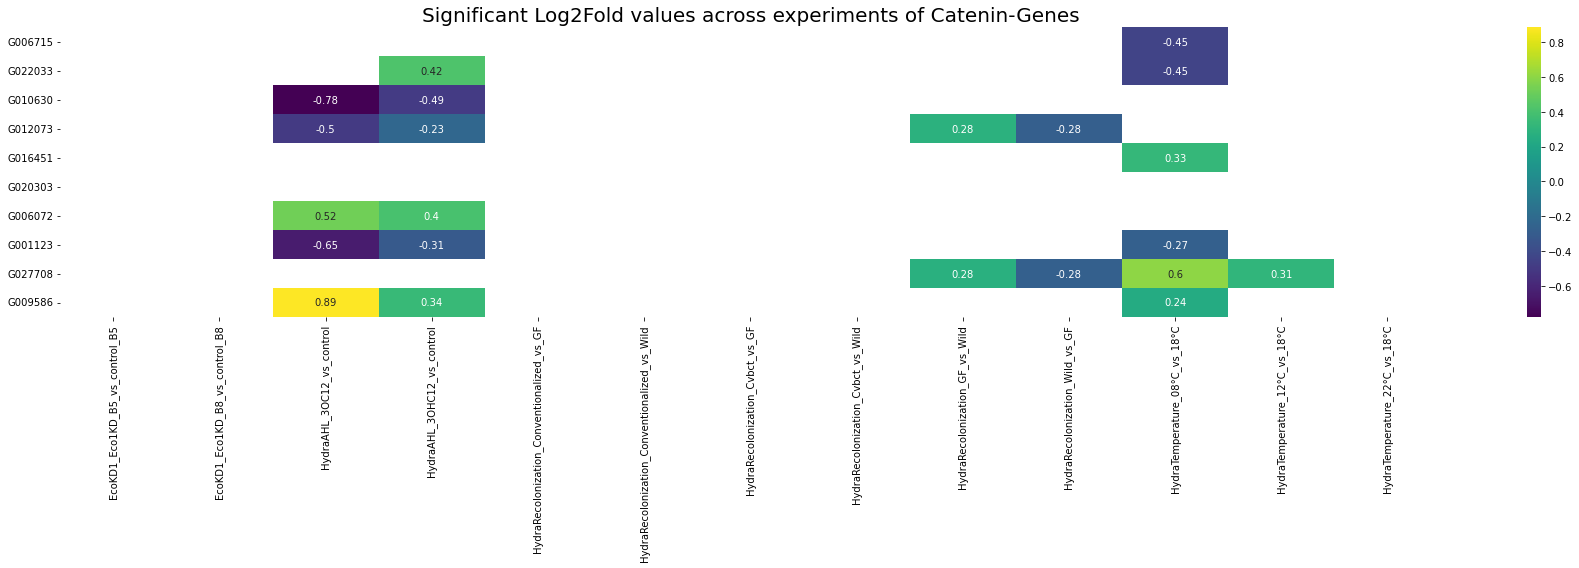

In [18]:
plt.figure(figsize=(25, 8))
custom_y_labels = catenin_genes_to_pval["gene_id"]
mask_matrix = catenin_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
sns.heatmap(catenin_genes_to_exp.iloc[:,1:], annot=True, cmap="viridis", mask=mask_matrix, yticklabels=custom_y_labels)
plt.title('Significant Log2Fold values across experiments of Catenin-Genes', fontsize=20)
plt.tight_layout()
plt.savefig("../results/figures/genes_tpm_heatmaps/catenin_log2_heatmap.jpg")

In [26]:
annot_mat = np.repeat(annotation_genes_to_catenin["KO_definition"].to_numpy()[np.newaxis, :], len(list(catenin_genes_to_exp.iloc[:,1:].columns)), axis=0).T
custom_yticklabels = catenin_genes_to_pval["gene_id"]
custom_xticklabels = list(catenin_genes_to_exp.iloc[:,1:].columns)

matrix = catenin_genes_to_exp.iloc[:,1:].to_numpy()
matrix = np.nan_to_num(matrix, nan=0)

pmat = catenin_genes_to_pval.iloc[:,1:].to_numpy()
pmat = np.nan_to_num(pmat, nan=1)
mask_matrix = pmat >= 0.05  # Example mask matrix

#mask_matrix = mask_matrix.to_numpy()
masked_matrix = np.where(mask_matrix, np.nan, matrix)
#masked_matrix = np.nan_to_num(masked_matrix, nan=0)

hover_text = list(annot_mat)
heatmap_masked = go.Heatmap(z=masked_matrix, hovertext=hover_text, hoverinfo='text', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)
heatmap_original = go.Heatmap(z=matrix, visible='legendonly', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create the figure
fig = go.Figure(data=[heatmap_masked, heatmap_original])
# Create the figure

# Update layout to set axis titles and hover mode
fig.update_layout(
    title='Catenin-Genes Log2FoldChange p-value masked array of RNA-Seq experiments',
    xaxis=dict(title='Log2FoldChange',  tickmode='array', tickvals=np.arange(len(custom_xticklabels)), ticktext=custom_xticklabels, showgrid=False, tickangle=45),
    yaxis=dict(title='Hydra Gene Identifier', tickmode='array', tickvals=np.arange(len(custom_yticklabels)), ticktext=custom_yticklabels, showgrid=False),
    hovermode='closest',
    #height=800,
)

# Show the plot
fig.show()
write_html(fig, '../results/figures/genes_tpm_heatmaps/heatmap_plot_catenin.html')

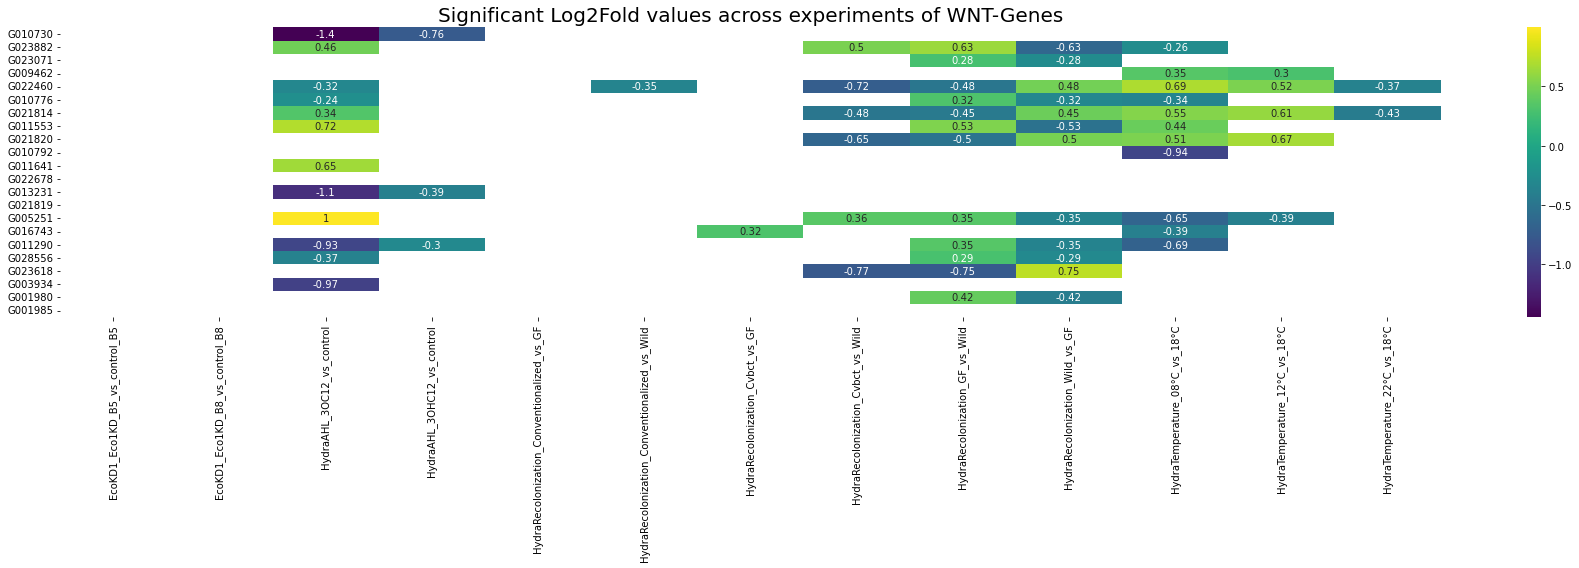

In [20]:
plt.figure(figsize=(25, 8))
custom_y_labels = wnt_genes_to_pval["gene_id"]
mask_matrix = wnt_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
sns.heatmap(wnt_genes_to_exp.iloc[:,1:], annot=True, cmap="viridis", mask=mask_matrix, yticklabels=custom_y_labels)
plt.title('Significant Log2Fold values across experiments of WNT-Genes', fontsize=20)
plt.tight_layout()
plt.savefig("../results/figures/genes_tpm_heatmaps/wnt_log2_heatmap.jpg")

In [21]:
annot_mat = np.repeat(annotation_genes_to_wnt["KO_definition"].to_numpy()[np.newaxis, :], len(list(wnt_genes_to_exp.iloc[:,1:].columns)), axis=0).T
custom_yticklabels = wnt_genes_to_pval["gene_id"]
custom_xticklabels = list(wnt_genes_to_exp.iloc[:,1:].columns)

matrix = wnt_genes_to_exp.iloc[:,1:].to_numpy()
mask_matrix = wnt_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
mask_matrix = mask_matrix.to_numpy()
masked_matrix = np.where(mask_matrix, np.nan, matrix)

# Create text to display above hovering cells
hover_text = list(annot_mat)#annotation_genes_to_wnt["KO_definition"].to_numpy() * 12#[['Value: {}'.format(value) for value in row] for row in wnt_genes_to_tpm.iloc[:,1:].to_numpy()]

# Create a heatmap trace

heatmap_masked = go.Heatmap(z=masked_matrix, hovertext=hover_text, hoverinfo='text', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create a heatmap trace for the original matrix (to show the unmasked areas)
heatmap_original = go.Heatmap(z=matrix, visible='legendonly', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create the figure
fig = go.Figure(data=[heatmap_masked, heatmap_original])
# Create the figure

# Update layout to set axis titles and hover mode
fig.update_layout(
    title='WNT-Genes Log2FoldChange p-value masked array of RNA-Seq experiments',
    xaxis=dict(title='Log2FoldChange',  tickmode='array', tickvals=np.arange(len(custom_xticklabels)), ticktext=custom_xticklabels, showgrid=False, tickangle=45),
    yaxis=dict(title='Hydra Gene Identifier', tickmode='array', tickvals=np.arange(len(custom_yticklabels)), ticktext=custom_yticklabels, showgrid=False),
    hovermode='closest',
    height=800,
)

# Show the plot
fig.show()
write_html(fig, '../results/figures/genes_tpm_heatmaps/heatmap_plot_wnt.html')

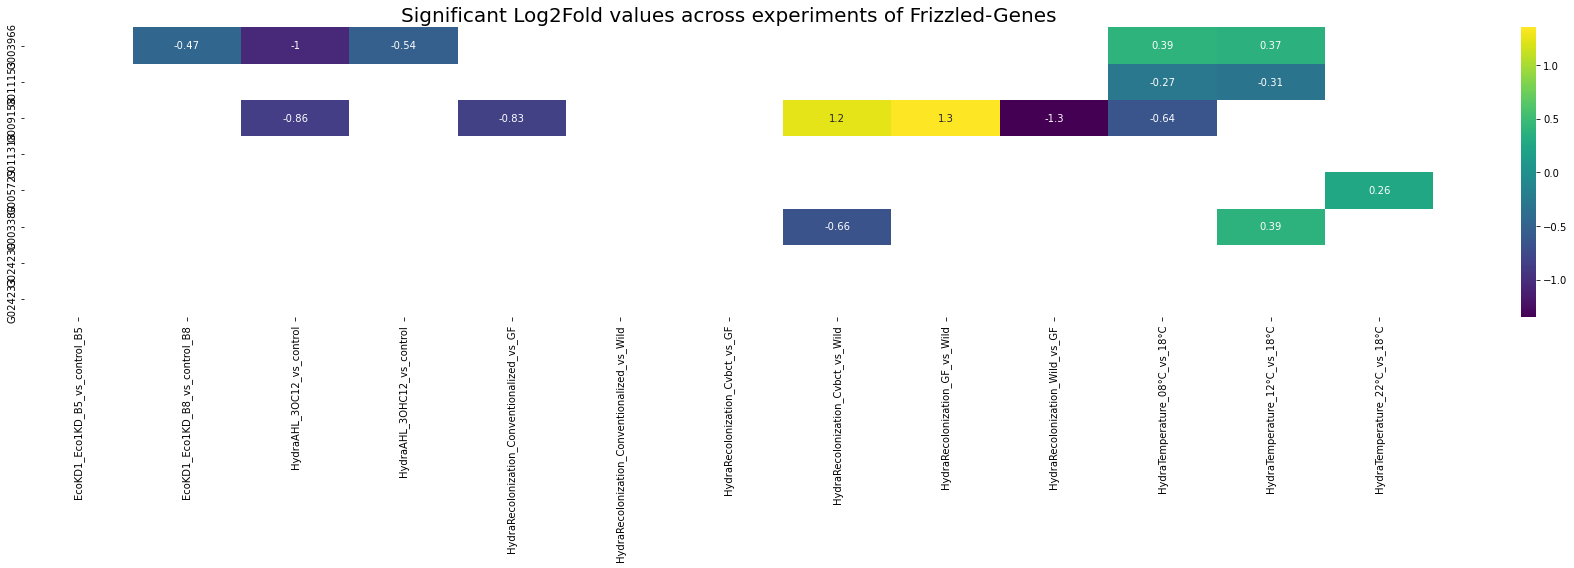

In [22]:
plt.figure(figsize=(25, 8))
custom_y_labels = frizzled_genes_to_pval["gene_id"]
mask_matrix = frizzled_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
sns.heatmap(frizzled_genes_to_exp.iloc[:,1:], annot=True, cmap="viridis", mask=mask_matrix, yticklabels=custom_y_labels)
plt.title('Significant Log2Fold values across experiments of Frizzled-Genes', fontsize=20)
plt.tight_layout()
plt.savefig("../results/figures/genes_tpm_heatmaps/frizzled_log2_heatmap.jpg")

In [23]:
annot_mat = np.repeat(annotation_genes_to_frizzled["KO_definition"].to_numpy()[np.newaxis, :], len(list(frizzled_genes_to_exp.iloc[:,1:].columns)), axis=0).T
custom_yticklabels = frizzled_genes_to_pval["gene_id"]
custom_xticklabels = list(frizzled_genes_to_exp.iloc[:,1:].columns)

matrix = frizzled_genes_to_exp.iloc[:,1:].to_numpy()
mask_matrix = frizzled_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
mask_matrix = mask_matrix.to_numpy()
masked_matrix = np.where(mask_matrix, np.nan, matrix)

# Create text to display above hovering cells
hover_text = list(annot_mat)#annotation_genes_to_wnt["KO_definition"].to_numpy() * 12#[['Value: {}'.format(value) for value in row] for row in wnt_genes_to_tpm.iloc[:,1:].to_numpy()]

# Create a heatmap trace

heatmap_masked = go.Heatmap(z=masked_matrix, hovertext=hover_text, hoverinfo='text', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create a heatmap trace for the original matrix (to show the unmasked areas)
heatmap_original = go.Heatmap(z=matrix, visible='legendonly', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create the figure
fig = go.Figure(data=[heatmap_masked, heatmap_original])
# Create the figure

# Update layout to set axis titles and hover mode
fig.update_layout(
    title='Frizzled-Genes Log2FoldChange p-value masked array of RNA-Seq experiments',
    xaxis=dict(title='Log2FoldChange',  tickmode='array', tickvals=np.arange(len(custom_xticklabels)), ticktext=custom_xticklabels, showgrid=False, tickangle=45),
    yaxis=dict(title='Hydra Gene Identifier', tickmode='array', tickvals=np.arange(len(custom_yticklabels)), ticktext=custom_yticklabels, showgrid=False),
    hovermode='closest',
    height=800,
)

# Show the plot
write_html(fig, '../results/figures/genes_tpm_heatmaps/heatmap_plot_frizzled.html')
fig.show()


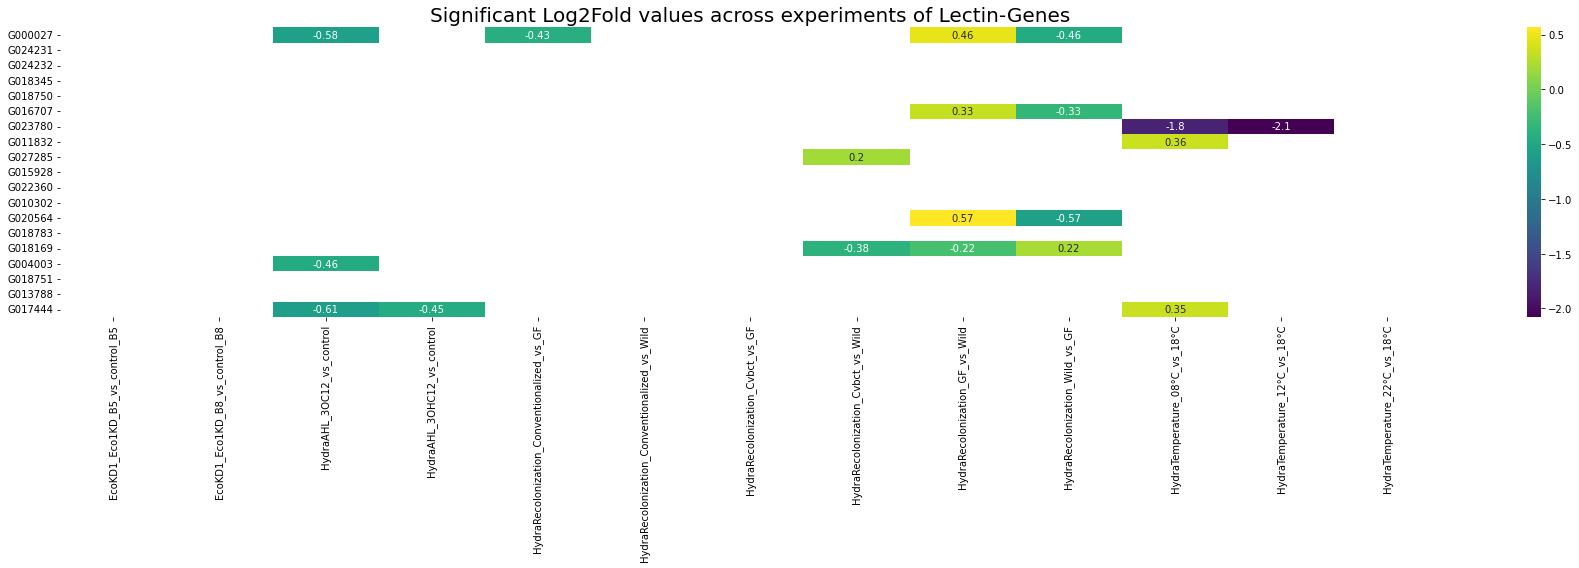

In [24]:
plt.figure(figsize=(25, 8))
custom_y_labels = lectin_genes_to_pval["gene_id"]
mask_matrix = lectin_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
sns.heatmap(lectin_genes_to_exp.iloc[:,1:], annot=True, cmap="viridis", mask=mask_matrix, yticklabels=custom_y_labels)
plt.title('Significant Log2Fold values across experiments of Lectin-Genes', fontsize=20)
plt.tight_layout()
plt.savefig("../results/figures/genes_tpm_heatmaps/lectin_log2_heatmap.jpg")

In [25]:
annot_mat = np.repeat(annotaion_genes_to_lectin["KO_definition"].to_numpy()[np.newaxis, :], len(list(lectin_genes_to_exp.iloc[:,1:].columns)), axis=0).T
custom_yticklabels = lectin_genes_to_pval["gene_id"]
custom_xticklabels = list(lectin_genes_to_exp.iloc[:,1:].columns)

matrix = lectin_genes_to_exp.iloc[:,1:].to_numpy()
mask_matrix = lectin_genes_to_pval.iloc[:,1:] >= 0.05  # Example mask matrix
mask_matrix = mask_matrix.to_numpy()
masked_matrix = np.where(mask_matrix, np.nan, matrix)

# Create text to display above hovering cells
hover_text = list(annot_mat)#annotation_genes_to_wnt["KO_definition"].to_numpy() * 12#[['Value: {}'.format(value) for value in row] for row in wnt_genes_to_tpm.iloc[:,1:].to_numpy()]

# Create a heatmap trace

heatmap_masked = go.Heatmap(z=masked_matrix, hovertext=hover_text, hoverinfo='text', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create a heatmap trace for the original matrix (to show the unmasked areas)
heatmap_original = go.Heatmap(z=matrix, visible='legendonly', colorscale='viridis', x=np.arange(len(matrix[0])), y=custom_yticklabels)

# Create the figure
fig = go.Figure(data=[heatmap_masked, heatmap_original])
# Create the figure

# Update layout to set axis titles and hover mode
fig.update_layout(
    title='Lectin-Genes Log2FoldChange p-value masked array of RNA-Seq experiments',
    xaxis=dict(title='Log2FoldChange',  tickmode='array', tickvals=np.arange(len(custom_xticklabels)), ticktext=custom_xticklabels, showgrid=False, tickangle=45),
    yaxis=dict(title='Hydra Gene Identifier', tickmode='array', tickvals=np.arange(len(custom_yticklabels)), ticktext=custom_yticklabels, showgrid=False),
    hovermode='closest',
    height=800,
)

# Show the plot
write_html(fig, '../results/figures/genes_tpm_heatmaps/heatmap_plot_lectin.html')
fig.show()
